In [ ]:
import io
import numpy as np
import pandas as pd
import requests
import zipfile

from google.colab import auth
from google.colab import drive
from google.auth import default
import gspread
from gspread_dataframe import set_with_dataframe
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
drive_service = build('drive', 'v3', credentials=creds)

In [ ]:
ATTR_COL = 'Attribute_Description'
COUNTRY_COL = 'Country_Name'
DEFAULT_YEAR = 'Market_Year'
USDA_BASE_URL = 'https://apps.fas.usda.gov/psdonline/downloads/'
DOWNLOAD_PATH = USDA_BASE_URL + 'psd_coffee_csv.zip'
FOLDER_ID = '1e9vMP4t1t4vQKAwgTOI8lFacUokSjMLG'
CSV_PATH = '/content/drive/My Drive/psd_coffee.csv'

In [ ]:
def export_df_to_sheet(df, name, folder_id):
    try:
        sheet = gc.open(name)
    except gspread.SpreadsheetNotFound:
        sheet = gc.create(name, folder_id=folder_id)
    ws = sheet.get_worksheet(0)
    set_with_dataframe(ws, df, resize=True)

    try:
        meta = drive_service.files().get(
            fileId=sheet.id,
            fields='parents',
            supportsAllDrives=True
        ).execute()
        parents = meta.get('parents', [])
        if folder_id not in parents:
            drive_service.files().update(
                fileId=sheet.id,
                addParents=folder_id,
                removeParents=",".join(parents),
                supportsAllDrives=True,
                fields='id, parents'
            ).execute()
    except HttpError:
        pass

In [ ]:
class usda(object):

    def __init__(self, datapath, year_type=DEFAULT_YEAR):
        try:
            data = pd.read_csv(datapath, index_col=0)
        except FileNotFoundError:
            self.refresh_data(outpath=datapath)
            data = pd.read_csv(datapath, index_col=0)

        self.attribute_list = sorted(list(data[ATTR_COL].unique()))
        self.country_list = sorted(list(data[COUNTRY_COL].unique()))
        self.year_type = year_type
        self.data = data

    def query_for_country(self, country, attributes=[], year_range=[]):
        df = self.data[self.data[COUNTRY_COL] == country]
        if attributes:
            df = df[df[ATTR_COL].isin(attributes)]
        df = df.pivot(
            index=self.year_type,
            columns=ATTR_COL,
            values='Value',
        ) * 1000
        df.index.name = 'Year'
        if year_range:
            df = df.loc[year_range[0]:year_range[1]]
        df.reset_index(inplace=True)
        return df

    def query_for_attribute(self, attribute, countries=[], year_range=[]):
        df = self.data[self.data[ATTR_COL] == attribute]
        if countries:
            df = df[df[COUNTRY_COL].isin(countries)]
        df = df.pivot(
            index=self.year_type,
            columns=COUNTRY_COL,
            values='Value',
        )
        df = df * 1000
        df.index.name = 'Year'
        if year_range:
            df = df.loc[year_range[0]:year_range[1]]
        df.reset_index(inplace=True)
        return df

    def refresh_data(self, outpath, url=DOWNLOAD_PATH):
        drive.mount('/content/drive')
        response = requests.get(url)
        zf = zipfile.ZipFile(io.BytesIO(response.content))

        members = [m for m in zf.namelist() if m.lower().endswith('.csv')]
        if not members:
            raise RuntimeError('no .csv file found in ZIP')
        csv_member = members[0]

        with zf.open(csv_member) as f:
            df = pd.read_csv(f)

        df.to_csv(outpath)
        self.data = df

In [ ]:
U = usda(datapath=CSV_PATH)

Mounted at /content/drive


In [ ]:
def cagr(series):

    if len(series) < 2:
        return None

    while not series.iloc[0]:
        series = series.iloc[1:]
        if len(series) < 2:
            return None

    start_value = series.iloc[0]
    end_value = series.iloc[-1]
    num_years = len(series) - 1

    if start_value == 0 or end_value == 0:
        return None

    cagr = ((end_value / start_value) ** (1 / num_years)) - 1
    return cagr * 100

def incremental(series):
    if len(series) < 2:
        return None

    start_value = series.iloc[0]
    series = series - start_value
    return series

## Demand side

### Mappings

In [ ]:
country_to_region = {
    # US & Canada
    'United States': 'US & Canada',
    'Canada': 'US & Canada',

    # Japan
    'Japan': 'Japan',

    # Europe
    'European Union': 'Europe',
    'Croatia': 'Eastern Europe & Central Asia',
    'Norway': 'Europe',
    'Switzerland': 'Europe',
    'United Kingdom': 'Europe',

    # Eastern Europe & Central Asia
    # https://www.unescwa.org/sd-glossary/europe-and-central-asia
    'Albania': 'Eastern Europe & Central Asia',
    'Armenia': 'Eastern Europe & Central Asia',
    'Bosnia and Herzegovina': 'Eastern Europe & Central Asia',
    'Georgia': 'Eastern Europe & Central Asia',
    'Kazakhstan': 'Eastern Europe & Central Asia',
    'Kosovo': 'Eastern Europe & Central Asia',
    'Montenegro': 'Eastern Europe & Central Asia',
    'North Macedonia': 'Eastern Europe & Central Asia',
    'Serbia': 'Eastern Europe & Central Asia',
    'Ukraine': 'Eastern Europe & Central Asia',
    'Russia': 'Eastern Europe & Central Asia',


    # Latin America
    'Brazil': 'Latin America',
    'Mexico': 'Latin America',
    'Argentina': 'Latin America',
    'Bolivia': 'Latin America',
    'Chile': 'Latin America',
    'Colombia': 'Latin America',
    'Ecuador': 'Latin America',
    'Guyana': 'Latin America',
    'Paraguay': 'Latin America',
    'Peru': 'Latin America',
    'Uruguay': 'Latin America',
    'Venezuela': 'Latin America',
    'Costa Rica': 'Latin America',
    'Cuba': 'Latin America',
    'Dominican Republic': 'Latin America',
    'El Salvador': 'Latin America',
    'Guatemala': 'Latin America',
    'Haiti': 'Latin America',
    'Honduras': 'Latin America',
    'Jamaica': 'Latin America',
    'Nicaragua': 'Latin America',
    'Panama': 'Latin America',
    'Trinidad and Tobago': 'Latin America',

    # Southeast Asia
    'Indonesia': 'Southeast Asia',
    'Laos': 'Southeast Asia',
    'Malaysia': 'Southeast Asia',
    'Philippines': 'Southeast Asia',
    'Singapore': 'Southeast Asia',
    'Thailand': 'Southeast Asia',
    'Vietnam': 'Southeast Asia',
    'India': 'Southeast Asia',
    'Sri Lanka': 'Southeast Asia',

    # Middle East & North Africa
    'Iran': 'Middle East & North Africa',
    'Jordan': 'Middle East & North Africa',
    'Saudi Arabia': 'Middle East & North Africa',
    'Yemen': 'Middle East & North Africa',
    'Yemen (Sanaa)': 'Middle East & North Africa',
    'Turkey': 'Middle East & North Africa',
    'Egypt': 'Middle East & North Africa',
    'Morocco': 'Middle East & North Africa',
    'Algeria': 'Middle East & North Africa',

    # Africa
    'Angola': 'Africa',
    'Benin': 'Africa',
    'Burundi': 'Africa',
    'Cameroon': 'Africa',
    'Central African Republic': 'Africa',
    'Congo (Brazzaville)': 'Africa',
    'Congo (Kinshasa)': 'Africa',
    'Cote d\'Ivoire': 'Africa',
    'Equatorial Guinea': 'Africa',
    'Ethiopia': 'Africa',
    'Gabon': 'Africa',
    'Ghana': 'Africa',
    'Guinea': 'Africa',
    'Kenya': 'Africa',
    'Liberia': 'Africa',
    'Madagascar': 'Africa',
    'Malawi': 'Africa',
    'Nigeria': 'Africa',
    'Rwanda': 'Africa',
    'Senegal': 'Africa',
    'Sierra Leone': 'Africa',
    'South Africa': 'Africa',
    'Tanzania': 'Africa',
    'Togo': 'Africa',
    'Uganda': 'Africa',
    'Zambia': 'Africa',
    'Zimbabwe': 'Africa',

    # East Asia
    'China': 'China / Korea / Taiwan',
    'Taiwan': 'China / Korea / Taiwan',
    'Korea, South': 'China / Korea / Taiwan',

    # Australia & NZ
    'Australia': 'Australia & Oceania',
    'New Zealand': 'Australia & Oceania',
    'New Caledonia': 'Australia & Oceania',
    'Papua New Guinea': 'Australia & Oceania'
}

country_to_dw_name = {
    'United States': 'United States of America',
    'Russia': 'Russian Federation',
    'Iran': 'Islamic Republic of Iran',
    'Egypt': 'Arab Republic of Egypt',
    'Yemen': 'Republic of Yemen',
    'Yemen (Sanaa)': 'Republic of Yemen',
    'Cote d\'Ivoire': "Côte d'Ivoire",
    'Laos': "Lao People's Democratic Republic",
    'Korea, South': 'Republic of Korea',
    'Venezuela': 'R. B. de Venezuela',
    'Congo (Kinshasa)': 'Democratic Republic of Congo',
    'Congo (Brazzaville)': 'Congo',
    'New Caledonia': 'New Zealand'
}
eu_dw_names = [
    'Austria',
    'Belgium',
    'Bulgaria',
    'Croatia',
    'Cyprus',
    'Czech Republic',
    'Denmark',
    'Estonia',
    'Finland',
    'France',
    'Germany',
    'Greece',
    'Hungary',
    'Ireland',
    'Italy',
    'Latvia',
    'Lithuania',
    'Luxembourg',
    'Malta',
    'Netherlands',
    'Poland',
    'Portugal',
    'Romania',
    'Slovak Republic',
    'Slovenia',
    'Spain',
    'Sweden'
]

### Analysis

In [ ]:
df_consumption = U.query_for_attribute(attribute='Domestic Consumption', year_range=[2005,2025]).set_index('Year')
_years = list(df_consumption.index)

df_consumption = df_consumption.T.reset_index()
df_consumption['DW_NAME'] = df_consumption['Country_Name'].apply(lambda x: country_to_dw_name.get(x,x))
df_consumption['Region'] = df_consumption['Country_Name'].map(country_to_region)
df_consumption = df_consumption.set_index(['Country_Name', 'DW_NAME', 'Region'])

In [ ]:
mature = ['US & Canada', 'Europe', 'Japan']
df_mature_consumption = df_consumption.reset_index()
df_mature_consumption['Category'] = df_mature_consumption['Region'].apply(lambda x: 'EU, Japan, US & Canada' if x in mature else 'Rest of World')
df_mature_consumption = (
    df_mature_consumption
    .drop(columns=['Country_Name', 'DW_NAME', 'Region'])
    .groupby('Category')
    .sum()
    .T
    .reset_index()
)
export_df_to_sheet(df_mature_consumption, "[Public] Consumption in Mature vs Young Markets", FOLDER_ID)

In [ ]:
df_consumption_cagr = (
    df_consumption
    .fillna(0)
    .reset_index()
    .drop(columns=['Country_Name', 'Region'])
    .groupby('DW_NAME')
    .sum()
    .T
    .apply(cagr)
    .sort_values(ascending=False)
    .reset_index()
)
df_consumption_cagr.columns = ['Country', 'CAGR']

eu_cagr = df_consumption_cagr.loc[
    df_consumption_cagr['Country'] == 'European Union', 'CAGR'
].values[0]
df_eu_split = pd.DataFrame({'Country': eu_dw_names, 'CAGR': eu_cagr})

df_consumption_cagr = pd.concat(
    [df_consumption_cagr[df_consumption_cagr['Country'] != 'European Union'],
    df_eu_split],
    ignore_index=True
)
export_df_to_sheet(df_consumption_cagr, "[Public] Domestic Consumption CAGR", FOLDER_ID)

In [ ]:
df_regional_consumption_cagr = (
    df_consumption
    .reset_index()
    .drop(columns=['Country_Name', 'DW_NAME'])
    .groupby('Region')
    .sum()
    .T
    .apply(cagr)
    .sort_values(ascending=False)
    .reset_index()
)
df_regional_consumption_cagr.columns = ['Region', 'CAGR']
export_df_to_sheet(df_regional_consumption_cagr, "[Public] Regional Domestic CAGR", FOLDER_ID)
df_regional_consumption_cagr

,Region,CAGR
0,China / Korea / Taiwan,8.862791
1,Southeast Asia,5.607754
2,Middle East & North Africa,4.364261
3,Australia & Oceania,3.434261
4,Africa,1.878417
5,Latin America,1.569404
6,US & Canada,0.969546
7,Eastern Europe & Central Asia,0.557871
8,Europe,0.146496
9,Japan,-0.410835


In [ ]:
df_brazil_conilon = U.query_for_country(country='Brazil', attributes=['Domestic Consumption', 'Robusta Production'], year_range=[1995,2025])
df_brazil_conilon.rename(columns={'Robusta Production': 'Conilon (Robusta) Production'}, inplace=True)
export_df_to_sheet(df_brazil_conilon, "[Public] Brazil Domestic Consumption & Conilon Production", FOLDER_ID)

In [ ]:
df_lac = df_consumption.reset_index()
df_lac = df_lac[(df_lac['Region'] == 'Latin America') & (df_lac['Country_Name'] != 'Brazil')].loc[:,2005:].sum(axis=0).reset_index()
df_lac.columns = ['Year', 'Domestic Consumption']
export_df_to_sheet(df_lac, "[Public] Latin America Domestic Consumption", FOLDER_ID)

In [ ]:
df_lac = df_consumption.reset_index()
df_lac = df_lac[(df_lac['Region'] == 'Latin America') & (df_lac['Country_Name'] != 'Brazil')]
df_lac = df_lac.set_index('Country_Name').loc[:,2011:]
df_lac = (
    pd
    .concat([df_lac.loc[:,2011:2015].mean(axis=1), df_lac.loc[:,2021:2025].mean(axis=1)], axis=1)
    .rename(columns={0: '2011-2015', 1: '2021-2025'})
    .sort_values(by='2021-2025', ascending=False)
    .iloc[:-4]
    .reset_index()
    .rename(columns={'Country_Name': 'Country'})
  )
df_lac = df_lac[df_lac['2011-2015'] > 200_000]
export_df_to_sheet(df_lac, "[Public] Latin America Domestic Consumption by Country", FOLDER_ID)
df_lac.sum(axis=0)

,0
Country,MexicoColombiaArgentinaGuatemalaVenezuelaHondu...
2011-2015,7920800.0
2021-2025,8898000.0


In [ ]:
df_eeca = df_consumption.reset_index()[df_consumption.reset_index()['Region'] == 'Eastern Europe & Central Asia'].set_index('Country_Name').loc[:,2011:]
df_eeca = (
    pd
    .concat([df_eeca.loc[:,2011:2015].mean(axis=1), df_eeca.loc[:,2021:2025].mean(axis=1)], axis=1)
    .rename(columns={0: '2011-2015', 1: '2021-2025'})
    .sort_values(by='2021-2025', ascending=False)
    .iloc[:-4]
    .reset_index()
    .rename(columns={'Country_Name': 'Country'})
  )
export_df_to_sheet(df_eeca, "[Public] Eastern Europe & Central Asia Domestic Consumption", FOLDER_ID)
df_eeca.sum(axis=0)

,0
Country,RussiaUkraineSerbiaKazakhstanBosnia and Herzeg...
2011-2015,6885000.0
2021-2025,7250400.0


In [ ]:
df_eeca = df_consumption.reset_index()[df_consumption.reset_index()['Region'] == 'Eastern Europe & Central Asia'].set_index('Country_Name').loc[:,2011:]
df_eeca = (
    pd
    .concat([df_eeca.loc[:,2011:2015].mean(axis=1), df_eeca.loc[:,2021:2025].mean(axis=1)], axis=1)
    .rename(columns={0: '2011-2015', 1: '2021-2025'})
    .sort_values(by='2021-2025', ascending=False)
    .iloc[:-4]
    .reset_index()
  )
export_df_to_sheet(df_eeca, "[Public] Eastern Europe & Central Asia Domestic Consumption", FOLDER_ID)
df_eeca.sum(axis=0)

,0
Country_Name,RussiaUkraineSerbiaKazakhstanBosnia and Herzeg...
2011-2015,6885000.0
2021-2025,7250400.0


In [ ]:
df_asia = df_consumption.reset_index()[df_consumption.reset_index()['Region'].isin(['China / Korea / Taiwan', 'Southeast Asia'])].set_index('Country_Name')

df_asia_all = df_asia.loc[:,2005:].sum(axis=0).reset_index(0)
df_asia_all.columns = ['Year', 'Domestic Consumption']
export_df_to_sheet(df_asia_all, "[Public] Asia Domestic Consumption Summary", FOLDER_ID)

df_asia = (
    pd
    .concat([df_asia.loc[:,2011:2015].mean(axis=1), df_asia.loc[:,2021:2025].mean(axis=1)], axis=1)
    .rename(columns={0: '2011-2015', 1: '2021-2025'})
    .sort_values(by='2021-2025', ascending=False)
    .iloc[:-4]
    .reset_index()
    .rename(columns={'Country_Name': 'Country'})
  )
export_df_to_sheet(df_asia, "[Public] Asia Domestic Consumption", FOLDER_ID)
df_asia.sum(axis=0)

,0
Country,"PhilippinesChinaIndonesiaVietnamKorea, SouthIn..."
2011-2015,15401200.0
2021-2025,26646800.0


In [ ]:
df_mena = df_consumption.reset_index()[df_consumption.reset_index()['Region'].isin(['Middle East & North Africa'])].set_index('Country_Name')

df_mena_all = df_mena.loc[:,2005:].sum(axis=0).reset_index(0)
df_mena_all.columns = ['Year', 'Domestic Consumption']
export_df_to_sheet(df_mena_all, "[Public] MENA Consumption Summary", FOLDER_ID)

df_asia = (
    pd
    .concat([df_mena.loc[:,2011:2015].mean(axis=1), df_mena.loc[:,2021:2025].mean(axis=1)], axis=1)
    .rename(columns={0: '2011-2015', 1: '2021-2025'})
    .sort_values(by='2021-2025', ascending=False)
    .iloc[:-4]
    .reset_index()
    .rename(columns={'Country_Name': 'Country'})
  )
export_df_to_sheet(df_mena, "[Public] MENA Domestic Consumption", FOLDER_ID)
df_mena.sum(axis=0)
df_mena

Year,DW_NAME,Region,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country_Name,,,,,,,,,,,,,,,,,,,,,
Algeria,Algeria,Middle East & North Africa,2085000.0,1840000.0,2050000.0,2070000.0,2080000.0,1815000.0,2270000.0,1945000.0,...,2205000.0,2300000.0,2340000.0,2040000.0,2240000.0,2090000.0,2050000.0,1950000.0,2050000.0,2050000.0
Egypt,Arab Republic of Egypt,Middle East & North Africa,80000.0,105000.0,225000.0,275000.0,150000.0,250000.0,500000.0,450000.0,...,630000.0,800000.0,825000.0,750000.0,400000.0,450000.0,900000.0,590000.0,425000.0,500000.0
Iran,Islamic Republic of Iran,Middle East & North Africa,NaN,NaN,175000.0,185000.0,325000.0,245000.0,260000.0,200000.0,...,405000.0,710000.0,515000.0,305000.0,425000.0,635000.0,800000.0,1040000.0,960000.0,1050000.0
Jordan,Jordan,Middle East & North Africa,180000.0,230000.0,290000.0,360000.0,330000.0,340000.0,350000.0,570000.0,...,625000.0,775000.0,835000.0,770000.0,845000.0,730000.0,725000.0,840000.0,950000.0,975000.0
Morocco,Morocco,Middle East & North Africa,530000.0,570000.0,580000.0,610000.0,590000.0,555000.0,715000.0,705000.0,...,660000.0,825000.0,845000.0,710000.0,880000.0,990000.0,805000.0,840000.0,1015000.0,1070000.0
Saudi Arabia,Saudi Arabia,Middle East & North Africa,545000.0,560000.0,595000.0,550000.0,600000.0,565000.0,685000.0,635000.0,...,840000.0,935000.0,980000.0,1040000.0,1200000.0,1140000.0,1380000.0,1375000.0,1525000.0,1500000.0
Turkey,Turkey,Middle East & North Africa,200000.0,240000.0,250000.0,275000.0,295000.0,340000.0,375000.0,490000.0,...,960000.0,865000.0,1205000.0,1215000.0,1165000.0,1285000.0,1590000.0,1545000.0,1700000.0,1735000.0
Yemen,Republic of Yemen,Middle East & North Africa,159000.0,170000.0,110000.0,115000.0,120000.0,125000.0,120000.0,125000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Yemen (Sanaa),Republic of Yemen,Middle East & North Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_soluble_consumption = U.query_for_attribute(attribute='Soluble Dom. Cons.', year_range=[2005,2025]).set_index('Year')
df_soluble_consumption = df_soluble_consumption.T.reset_index()
df_soluble_consumption['DW_NAME'] = df_soluble_consumption['Country_Name'].apply(lambda x: country_to_dw_name.get(x,x))
df_soluble_consumption['Region'] = df_soluble_consumption['Country_Name'].map(country_to_region)
df_soluble_consumption = df_soluble_consumption.set_index(['Country_Name', 'DW_NAME', 'Region'])
df_soluble_consumption = df_soluble_consumption[df_soluble_consumption[2025] > 0]

In [ ]:
df_soluble_consumption

,,Year,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country_Name,DW_NAME,Region,,,,,,,,,,,,,,,,,,,,,
Algeria,Algeria,Middle East & North Africa,10000.0,15000.0,25000.0,25000.0,20000.0,45000.0,30000.0,30000.0,25000.0,30000.0,...,40000.0,30000.0,40000.0,40000.0,40000.0,40000.0,50000.0,50000.0,50000.0,50000.0
Argentina,Argentina,Latin America,170000.0,175000.0,200000.0,200000.0,240000.0,290000.0,240000.0,260000.0,255000.0,250000.0,...,245000.0,300000.0,260000.0,310000.0,350000.0,360000.0,400000.0,250000.0,319000.0,350000.0
Australia,Australia,Australia & Oceania,250000.0,190000.0,260000.0,275000.0,290000.0,275000.0,310000.0,310000.0,250000.0,275000.0,...,125000.0,200000.0,265000.0,375000.0,210000.0,365000.0,290000.0,415000.0,550000.0,500000.0
Brazil,Brazil,Latin America,915000.0,970000.0,1000000.0,1000000.0,1040000.0,1090000.0,1120000.0,1110000.0,1080000.0,1095000.0,...,1125000.0,1145000.0,1180000.0,929000.0,930000.0,940000.0,950000.0,960000.0,970000.0,980000.0
Canada,Canada,US & Canada,480000.0,760000.0,840000.0,925000.0,1160000.0,1070000.0,1165000.0,1225000.0,1350000.0,1280000.0,...,1300000.0,1430000.0,1400000.0,1515000.0,1660000.0,1840000.0,1960000.0,1815000.0,1800000.0,1900000.0
China,China,China / Korea / Taiwan,59000.0,69000.0,50000.0,116000.0,225000.0,300000.0,450000.0,694000.0,993000.0,870000.0,...,1350000.0,1520000.0,1530000.0,1775000.0,1825000.0,2170000.0,1975000.0,1870000.0,1800000.0,1900000.0
Colombia,Colombia,Latin America,270000.0,290000.0,300000.0,300000.0,300000.0,300000.0,300000.0,300000.0,300000.0,300000.0,...,390000.0,450000.0,450000.0,500000.0,600000.0,600000.0,600000.0,610000.0,620000.0,620000.0
Costa Rica,Costa Rica,Latin America,13000.0,18000.0,16000.0,18000.0,17000.0,22000.0,22000.0,24000.0,28000.0,34000.0,...,25000.0,27000.0,5000.0,5000.0,20000.0,5000.0,5000.0,5000.0,5000.0,5000.0
Ecuador,Ecuador,Latin America,140000.0,145000.0,150000.0,160000.0,150000.0,190000.0,214000.0,225000.0,225000.0,225000.0,...,180000.0,193000.0,197000.0,265000.0,189000.0,160000.0,269000.0,310000.0,313000.0,325000.0


In [ ]:
df_asia_soluble = df_soluble_consumption.reset_index()[df_soluble_consumption.reset_index()['Region'].isin(['China / Korea / Taiwan', 'Southeast Asia'])].set_index('Country_Name')
df_asia_soluble

Year,DW_NAME,Region,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Country_Name,,,,,,,,,,,,,,,,,,,,,
China,China,China / Korea / Taiwan,59000.0,69000.0,50000.0,116000.0,225000.0,300000.0,450000.0,694000.0,...,1350000.0,1520000.0,1530000.0,1775000.0,1825000.0,2170000.0,1975000.0,1870000.0,1800000.0,1900000.0
India,India,Southeast Asia,170000.0,200000.0,245000.0,215000.0,210000.0,205000.0,380000.0,350000.0,...,650000.0,690000.0,720000.0,670000.0,763000.0,650000.0,675000.0,880000.0,900000.0,950000.0
Indonesia,Indonesia,Southeast Asia,215000.0,280000.0,370000.0,345000.0,300000.0,475000.0,470000.0,645000.0,...,810000.0,910000.0,1200000.0,1500000.0,1450000.0,1500000.0,1511000.0,1515000.0,1530000.0,1540000.0
Malaysia,Malaysia,Southeast Asia,390000.0,450000.0,520000.0,515000.0,480000.0,455000.0,625000.0,625000.0,...,670000.0,600000.0,850000.0,635000.0,800000.0,750000.0,675000.0,400000.0,500000.0,500000.0
Philippines,Philippines,Southeast Asia,1090000.0,1275000.0,1190000.0,1595000.0,2124000.0,2700000.0,3560000.0,4305000.0,...,6745000.0,6110000.0,5725000.0,5720000.0,6185000.0,6690000.0,5885000.0,5980000.0,5725000.0,6250000.0
Thailand,Thailand,Southeast Asia,280000.0,275000.0,270000.0,280000.0,327000.0,300000.0,270000.0,285000.0,...,300000.0,400000.0,530000.0,525000.0,425000.0,525000.0,500000.0,680000.0,700000.0,700000.0
Vietnam,Vietnam,Southeast Asia,40000.0,50000.0,75000.0,100000.0,120000.0,137000.0,185000.0,200000.0,...,370000.0,380000.0,390000.0,500000.0,500000.0,550000.0,550000.0,900000.0,1000000.0,1000000.0


In [ ]:

#df_consumption.apply(cagr).sort_values(ascending=False).head(20)
#df_consumption.apply(incremental).plot()

#export_df_to_sheet(df_consumption, "[Temp] Domestic Consumption", FOLDER_ID)

#df_regional_consumption = df_consumption.drop(columns=['Country_Name', 'DW_NAME']).groupby('Region').sum()


#.sort_values(ascending=False).plot(kind='barh')
# df_regional_consumption = df_regional_consumption.T
# df_regional_consumption.apply(cagr)#.sort_values()

,0
Region,
Africa,1.878417
Australia & Oceania,3.434261
China / Korea / Taiwan,8.862791
Eastern Europe & Central Asia,0.557871
Europe,0.146496
Japan,-0.410835
Latin America,1.569404
Middle East & North Africa,4.364261
Southeast Asia,5.607754


<Axes: xlabel='Year'>

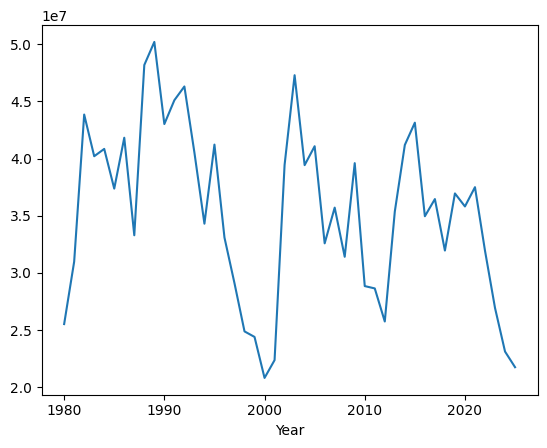

In [ ]:
U.query_for_attribute(attribute='Beginning Stocks', year_range=[1980, 2025]).set_index('Year').sum(axis=1).plot()

## Supply side

In [ ]:
df_brazil = U.query_for_country(country='Brazil', attributes=['Production'])
export_df_to_sheet(df_brazil, "[Public] Brazil USDA Production", FOLDER_ID)

In [ ]:
df_vietnam = U.query_for_country(country='Vietnam', attributes=['Production'], year_range=[1985,2025])
export_df_to_sheet(df_vietnam, "[Public] Vietnam USDA Production", FOLDER_ID)

In [ ]:
df_angola = U.query_for_country(country='Angola', attributes=['Production'])
export_df_to_sheet(df_angola, "[Public] Angola USDA Production", FOLDER_ID)

In [ ]:
LATAM_COUNTRIES = [
    'Colombia',
    'Honduras',
    'Peru',
    'Mexico',
    'Guatemala',
    'Nicaragua',
    'Costa Rica',
    'El Salvador',
]
df_latam = U.query_for_attribute(
    attribute='Production',
    countries=LATAM_COUNTRIES,
    year_range=[1995, 2025]
)
export_df_to_sheet(df_latam, "[Public] Latin America USDA Production", FOLDER_ID)

In [ ]:
df_latam_consolidated = df_latam.set_index('Year').copy()
df_latam_consolidated['Total'] = df_latam_consolidated.sum(axis=1)
df_latam_consolidated['Central America & Peru'] = df_latam_consolidated['Total'] - df_latam_consolidated['Colombia']
df_latam_consolidated = df_latam_consolidated[['Colombia', 'Central America & Peru']].reset_index()
export_df_to_sheet(df_latam_consolidated, "[Public] Latin America USDA Production (Consolidated)", FOLDER_ID)

In [ ]:
df_indonesia = U.query_for_country(
    country='Indonesia',
    attributes=['Production', 'Domestic Consumption'],
    year_range=[2005, 2025]
)
export_df_to_sheet(df_indonesia, "[Public] Indonesia USDA Production & Consumption", FOLDER_ID)

In [ ]:
df_india = U.query_for_country(
    country='India',
    attributes=['Production', 'Domestic Consumption'],
    year_range=[2005, 2025]
)
export_df_to_sheet(df_india, "[Public] India USDA Production & Consumption", FOLDER_ID)

In [ ]:
df_africa = U.query_for_attribute(
    attribute='Production',
    countries=[
        'Ethiopia',
        'Uganda',
        'Tanzania',
        'Kenya',
        'Rwanda',
        'Burundi'
    ],
    year_range=[1995, 2025]
)
export_df_to_sheet(df_africa, "[Public] East Africa USDA Production", FOLDER_ID)

In [ ]:
df = df_africa.set_index('Year')
df['Rest of Africa'] = df[['Kenya','Rwanda','Burundi']].sum(axis=1)
df = df.loc[2005:]

baseline = df.loc[2005]
df_inc = df.subtract(baseline, axis=1)
df_inc = df_inc[['Ethiopia','Uganda','Tanzania','Rest of Africa']].reset_index()
export_df_to_sheet(df_inc, "[Public] East Africa Incremental Production", FOLDER_ID)

In [ ]:
_df_all = U.query_for_attribute(attribute='Production').set_index('Year')
_df_all['Total'] = _df_all.sum(axis=1)
_df_all['Latin America'] = _df_all[LATAM_COUNTRIES].sum(axis=1)
_df_all['Rest of World'] = (
    _df_all['Total'] -
    _df_all['Brazil'] -
    _df_all['Latin America'] -
    _df_all['Vietnam']
)
share_cols = ['Brazil', 'Vietnam', 'Latin America', 'Rest of World']
df_share = (
    _df_all
      .assign(**{c: _df_all[c] / _df_all['Total'] for c in share_cols})
      .loc[:, share_cols]
).reset_index()
export_df_to_sheet(df_share, "[Public] Latin America vs RoW Production", FOLDER_ID)

<Axes: xlabel='Year'>

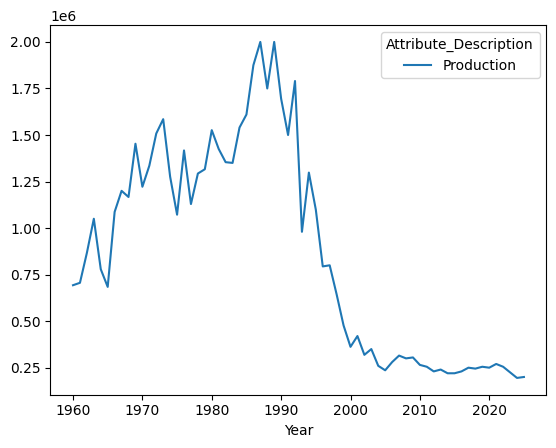

In [ ]:
U.query_for_country(country='Congo (Kinshasa)', attributes=['Production']).set_index('Year').plot()

In [ ]:
U.query_for_attribute(attribute='Production').columns

Index(['Year', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil',
       'Burundi', 'Cameroon', 'Canada', 'Central African Republic', 'Chile',
       'China', 'Colombia', 'Congo (Brazzaville)', 'Congo (Kinshasa)',
       'Costa Rica', 'Cote d'Ivoire', 'Croatia', 'Cuba', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Ethiopia',
       'European Union', 'Gabon', 'Georgia', 'Ghana', 'Guatemala', 'Guinea',
       'Guyana', 'Haiti', 'Honduras', 'India', 'Indonesia', 'Iran', 'Jamaica',
       'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Korea, South', 'Kosovo',
       'Laos', 'Liberia', 'Madagascar', 'Malawi', 'Malaysia', 'Mexico',
       'Montenegro', 'Morocco', 'New Caledonia', 'New Zealand', 'Nicaragua',
       'Nigeria', 'North Macedonia', 'Norway', 'Panama', 'Papua New Guinea',
       'Paraguay', 'Peru', 'Philippines', 'Russia', 'Rwanda', 'Saudi Arabia',
       'Senegal'

<Axes: xlabel='Year'>

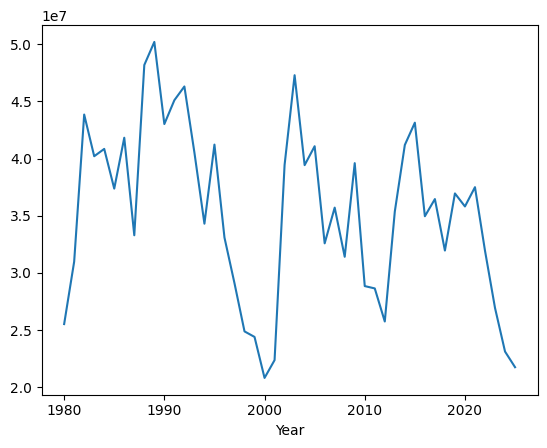